# EfficientNet-B0 Multiclass

In [1]:
# --- Kaggle: Download ADNI (same pattern as team notebooks) ---
import os, subprocess
from pathlib import Path

GDRIVE_FILE_ID = '1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz'
WORK_DIR = Path('/kaggle/working')
ADNI_ZIP_PATH = WORK_DIR / 'adni_dataset.zip'

if not os.path.exists(WORK_DIR / 'CN'):
    subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
    import gdown
    gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', str(ADNI_ZIP_PATH), quiet=False)
    import zipfile
    with zipfile.ZipFile(str(ADNI_ZIP_PATH), 'r') as zf:
        zf.extractall(str(WORK_DIR))
    ADNI_ZIP_PATH.unlink(missing_ok=True)

ADNI_DIR = str(WORK_DIR)
for root, dirs, files in os.walk(WORK_DIR):
    if 'CN' in dirs and 'MCI' in dirs and 'AD' in dirs:
        ADNI_DIR = root
        break
print(f'ADNI_DIR = {ADNI_DIR}')

Downloading...
From (original): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz
From (redirected): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz&confirm=t&uuid=d6958639-2db9-45db-aeaf-b46f95644677
To: /kaggle/working/adni_dataset.zip
100%|██████████| 387M/387M [00:03<00:00, 113MB/s]  


ADNI_DIR = /kaggle/working/adni_nifti_preprocessed


In [2]:
%pip install -q captum lime scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 16.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import random
import json
import shutil
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

import torch._dynamo
torch._dynamo.config.suppress_errors = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [4]:
DATA_ROOT = ADNI_DIR
OUTPUT_DIR = '/kaggle/working/preprocessed_multiclass_effnet'
CKPT_DIR = '/kaggle/working/checkpoints_effnet_multiclass'
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE = 224
TRAIN_RATIO = 0.80
BATCH_SIZE = 32
NUM_EPOCHS = 40
PATIENCE = 10

PREPROCESS_MODE = 'rgb'

STRICT_PHASE2_LR = False
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4

LR_HEAD = 1e-3
LR_BACKBONE = 1e-4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

print(f'DATA_ROOT={DATA_ROOT} | PREPROCESS_MODE={PREPROCESS_MODE} | STRICT_PHASE2_LR={STRICT_PHASE2_LR}')

DATA_ROOT=/kaggle/working/adni_nifti_preprocessed | PREPROCESS_MODE=rgb | STRICT_PHASE2_LR=False


In [5]:
all_paths = []
all_labels = []

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f'Classes: {CLASS_NAMES}  (K={len(CLASS_NAMES)})')

for idx, cls in enumerate(CLASS_NAMES):
    cls_root = os.path.join(DATA_ROOT, cls)
    for dirpath, _, fnames in os.walk(cls_root):
        for fname in fnames:
            if os.path.splitext(fname)[1].lower() in VALID_EXTS:
                all_paths.append(os.path.join(dirpath, fname))
                all_labels.append(idx)

print(f'Total images: {len(all_paths)}')
for idx, cls in enumerate(CLASS_NAMES):
    print(f'  {cls}: {all_labels.count(idx)}')

Classes: ['AD', 'CN', 'MCI']  (K=3)
Total images: 8512
  AD: 1434
  CN: 2341
  MCI: 4737


In [6]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=1 - TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)

print(f'Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')

Train: 6809 | Val: 851 | Test: 852


In [7]:
train_set, val_set, test_set = set(train_paths), set(val_paths), set(test_paths)
print(f'Train-Val overlap: {len(train_set & val_set)}')
print(f'Train-Test overlap: {len(train_set & test_set)}')
print(f'Val-Test overlap: {len(val_set & test_set)}')
assert not (train_set & val_set) and not (train_set & test_set) and not (val_set & test_set)
print('OK: no path overlap between splits.')

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0
OK: no path overlap between splits.


In [8]:
print('Class distribution:')
for name, lbls in [('train', train_labels), ('val', val_labels), ('test', test_labels)]:
    c = Counter(lbls)
    print(f'  {name}: {dict(sorted(c.items()))}')

Class distribution:
  train: {0: 1147, 1: 1873, 2: 3789}
  val: {0: 143, 1: 234, 2: 474}
  test: {0: 144, 1: 234, 2: 474}


In [9]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

filename_usage = {}

def tensor_from_image(path):
    if PREPROCESS_MODE == 'rgb':
        img = Image.open(path).convert('RGB')
        img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
        t = transforms.ToTensor()(img)
        return (t * 255).byte()
    if PREPROCESS_MODE == 'gray3':
        img = Image.open(path).convert('L')
        img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
        t = transforms.ToTensor()(img)
        t = (t * 255).byte().repeat(3, 1, 1)
        return t
    raise ValueError('PREPROCESS_MODE must be rgb or gray3')

def save_tensors(paths, labels, split_name):
    split_dir = os.path.join(OUTPUT_DIR, split_name)
    for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f'Saving {split_name}'):
        cls_name = CLASS_NAMES[label]
        out_dir = os.path.join(split_dir, cls_name)
        os.makedirs(out_dir, exist_ok=True)
        base_fname = os.path.splitext(os.path.basename(path))[0]
        tracking_key = f'{cls_name}_{base_fname}'
        if tracking_key in filename_usage:
            filename_usage[tracking_key] += 1
            unique_fname = f'{base_fname}_dup{filename_usage[tracking_key]}.pt'
        else:
            filename_usage[tracking_key] = 0
            unique_fname = f'{base_fname}.pt'
        out_path = os.path.join(out_dir, unique_fname)
        tensor = tensor_from_image(path)
        torch.save(tensor, out_path)

save_tensors(train_paths, train_labels, 'train')
save_tensors(val_paths, val_labels, 'val')
save_tensors(test_paths, test_labels, 'test')
print('All tensors saved.')

Saving test: 100%|██████████| 852/852 [00:01<00:00, 452.43it/s]

All tensors saved.


In [10]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
])

class AlzheimerDataset(Dataset):
    def __init__(self, split_dir, class_names, augment=False):
        self.samples = []
        self.augment = augment
        for idx, cls in enumerate(class_names):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.endswith('.pt'):
                    self.samples.append((os.path.join(cls_dir, fname), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        tensor = torch.load(path, weights_only=True).float() / 255.0
        if self.augment:
            tensor = train_augment(tensor)
        return normalize(tensor), label

    def get_labels(self):
        return [s[1] for s in self.samples]

In [11]:
train_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, 'train'), CLASS_NAMES, augment=True)
val_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, 'val'), CLASS_NAMES)
test_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, 'test'), CLASS_NAMES)
print(f'Dataset sizes — Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Dataset sizes — Train: 6809 | Val: 851 | Test: 852


In [12]:
train_labels_list = train_ds.get_labels()
class_counts = Counter(train_labels_list)
print(f'Training class distribution: {dict(sorted(class_counts.items()))}')

sample_weights = [1.0 / class_counts[label] for label in train_labels_list]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

nw = min(4, os.cpu_count() or 1)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=nw, pin_memory=True, persistent_workers=(nw > 0))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=nw, pin_memory=True, persistent_workers=(nw > 0))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=nw, pin_memory=True, persistent_workers=(nw > 0))

Training class distribution: {0: 1147, 1: 1873, 2: 3789}


In [13]:
def build_efficientnet_b0_multiclass(num_classes: int) -> nn.Module:
    w = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=w)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

In [14]:
model = build_efficientnet_b0_multiclass(num_classes=len(CLASS_NAMES)).to(device)
criterion = nn.CrossEntropyLoss()

if STRICT_PHASE2_LR:
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    print('Optimizer: SGD (STRICT_PHASE2_LR) — warning: high LR on pretrained backbone')
else:
    optimizer = optim.AdamW(
        [
            {'params': model.features.parameters(), 'lr': LR_BACKBONE},
            {'params': model.classifier.parameters(), 'lr': LR_HEAD},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    print(f'Optimizer: AdamW | lr_backbone={LR_BACKBONE} | lr_head={LR_HEAD}')

scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
print(f'Model params: {sum(p.numel() for p in model.parameters()):,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 192MB/s]


Optimizer: AdamW | lr_backbone=0.0001 | lr_head=0.001
Model params: 4,011,391


In [15]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc=''):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    dev_type = 'cuda' if device.type == 'cuda' else 'cpu'
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    with torch.enable_grad() if is_train else torch.no_grad():
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=dev_type, enabled=(device.type == 'cuda')):
                outputs = model(images)
                loss = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / max(total, 1), correct / max(total, 1), all_preds, all_labels

In [16]:
ckpt_path = os.path.join(CKPT_DIR, 'best_efficientnet_b0_multiclass.pt')
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
patience_ctr = 0

print('=' * 60)
print('  TRAINING MULTI-CLASS CLASSIFIER (EfficientNet-B0)')
print(f'  Classes: {CLASS_NAMES}')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(train_loader, model, criterion, optimizer, scaler, desc=f'Ep{epoch}/{NUM_EPOCHS} [train]')
    vl_loss, vl_acc, val_preds, val_labels = run_epoch(val_loader, model, criterion, desc=f'Ep{epoch}/{NUM_EPOCHS} [val]')
    precision, recall, f1, _ = precision_recall_fscore_support(val_labels, val_preds, average=None, zero_division=0)
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    print(f'Epoch {epoch:02d} | train loss={tr_loss:.4f} acc={tr_acc*100:.2f}% | val loss={vl_loss:.4f} acc={vl_acc*100:.2f}%')
    print(f"  Val per-class F1: {[f'{x:.3f}' for x in f1]}")
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), ckpt_path)
        patience_ctr = 0
        print(f'  Best val_acc={best_val_acc*100:.2f}% — saved.')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}.')
            break

print(f'\nBest validation accuracy: {best_val_acc*100:.2f}%')

  TRAINING MULTI-CLASS CLASSIFIER (EfficientNet-B0)
  Classes: ['AD', 'CN', 'MCI']


Epoch 01 | train loss=0.7709 acc=63.34% | val loss=0.5801 acc=74.85%
  Val per-class F1: ['0.717', '0.741', '0.767']
  Best val_acc=74.85% — saved.


Epoch 02 | train loss=0.4128 acc=83.58% | val loss=0.2406 acc=89.19%
  Val per-class F1: ['0.930', '0.857', '0.900']
  Best val_acc=89.19% — saved.


Epoch 03 | train loss=0.2304 acc=91.35% | val loss=0.1033 acc=96.71%
  Val per-class F1: ['0.972', '0.957', '0.971']
  Best val_acc=96.71% — saved.


Epoch 04 | train loss=0.1544 acc=94.30% | val loss=0.1078 acc=95.89%
  Val per-class F1: ['0.950', '0.955', '0.963']


...

Epoch 25 | train loss=0.0148 acc=99.54% | val loss=0.0003 acc=100.00%
  Val per-class F1: ['1.000', '1.000', '1.000']


Epoch 26 | train loss=0.0126 acc=99.44% | val loss=0.0230 acc=99.53%
  Val per-class F1: ['1.000', '0.991', '0.996']


Epoch 27 | train loss=0.0183 acc=99.43% | val loss=0.0056 acc=99.65%
  Val per-class F1: ['0.996', '0.994', '0.998']


Epoch 28 | train loss=0.0263 acc=99.02% | val loss=0.0016 acc=99.88%
  Val per-class F1: ['0.997', '1.000', '0.999']


Epoch 29 | train loss=0.0193 acc=99.34% | val loss=0.0030 acc=99.88%
  Val per-class F1: ['1.000', '0.998', '0.999']
  Early stopping at epoch 29.

Best validation accuracy: 100.00%


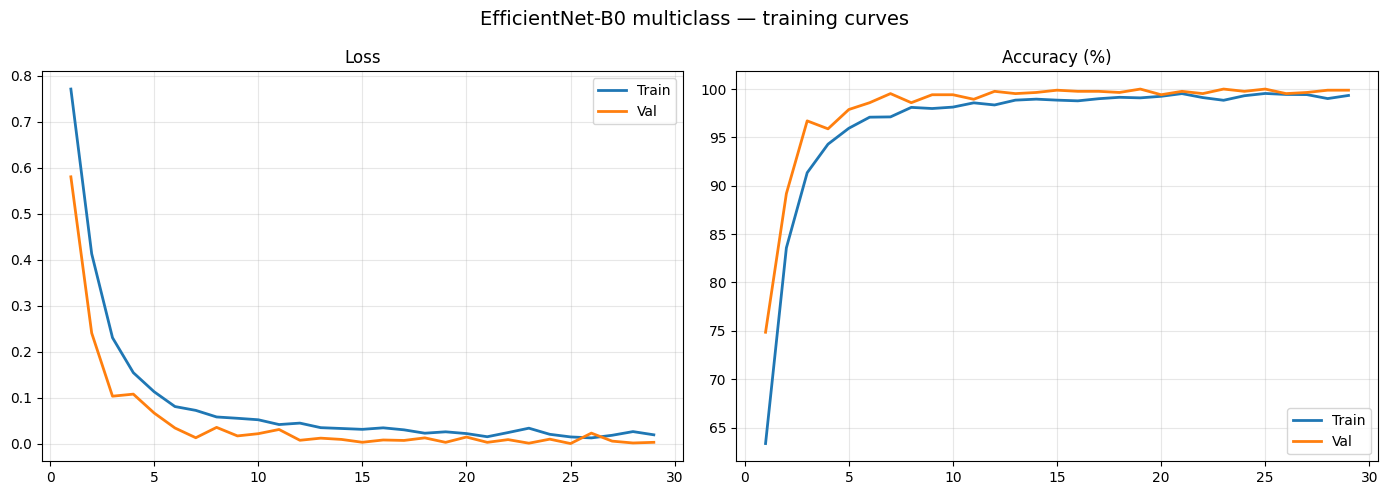

In [17]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNet-B0 multiclass — training curves', fontsize=14)
axes[0].plot(epochs_range, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Val', linewidth=2)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_range, [a * 100 for a in history['train_acc']], label='Train', linewidth=2)
axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']], label='Val', linewidth=2)
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'curves_multiclass_effnet.png'), dpi=150)
plt.show()

In [18]:
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()
test_loss, test_acc, test_preds, test_labels = run_epoch(test_loader, model, criterion, desc='Test')
print(f'Test loss={test_loss:.4f} | Test acc={test_acc*100:.2f}%')

Test loss=0.0101 | Test acc=99.77%


In [19]:
print('\n', classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))
precision, recall, f1, support = precision_recall_fscore_support(test_labels, test_preds, average=None, zero_division=0)
print('\nPer-class:')
print('-' * 60)
for i, cls in enumerate(CLASS_NAMES):
    print(f'{cls:15s} | P={precision[i]:.4f} | R={recall[i]:.4f} | F1={f1[i]:.4f} | support={support[i]}')
macro_f1 = float(np.mean(f1))
weighted_f1 = float(np.average(f1, weights=support))
print(f'\nMacro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}')


               precision    recall  f1-score   support

          AD     1.0000    1.0000    1.0000       144
          CN     0.9915    1.0000    0.9957       234
         MCI     1.0000    0.9958    0.9979       474

    accuracy                         0.9977       852
   macro avg     0.9972    0.9986    0.9979       852
weighted avg     0.9977    0.9977    0.9977       852


Per-class:
------------------------------------------------------------
AD              | P=1.0000 | R=1.0000 | F1=1.0000 | support=144
CN              | P=0.9915 | R=1.0000 | F1=0.9957 | support=234
MCI             | P=1.0000 | R=0.9958 | F1=0.9979 | support=474

Macro F1: 0.9979 | Weighted F1: 0.9977


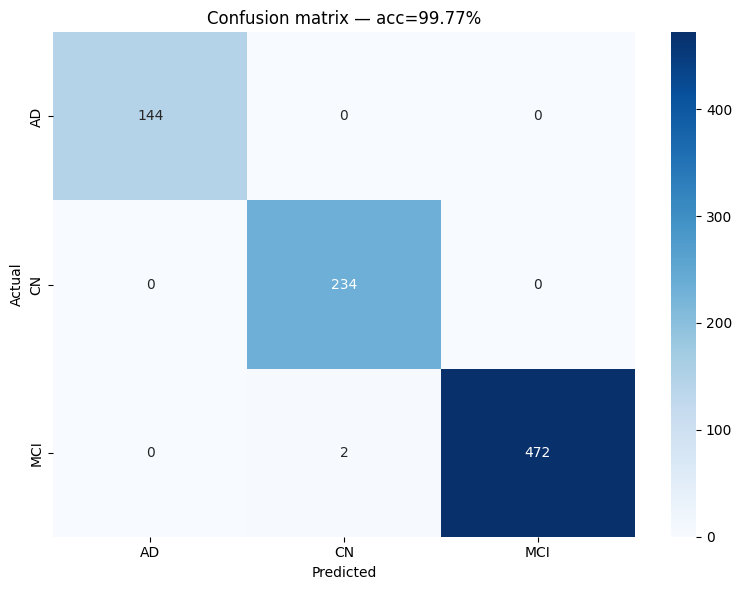

In [20]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title(f'Confusion matrix — acc={test_acc*100:.2f}%')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'cm_multiclass_effnet.png'), dpi=150)
plt.show()

In [21]:
results = {
    'paper': 'Savas 2022 Arabian Journal for Science and Engineering 10.1007/s13369-021-06131-3',
    'protocol_note': 'Phase2-style slice split + WeightedRandomSampler + EfficientNet-B0 ImageNet',
    'preprocess_mode': PREPROCESS_MODE,
    'strict_phase2_lr': STRICT_PHASE2_LR,
    'num_classes': len(CLASS_NAMES),
    'class_names': CLASS_NAMES,
    'best_val_acc': float(best_val_acc),
    'test_acc': float(test_acc),
    'test_loss': float(test_loss),
    'macro_f1': macro_f1,
    'weighted_f1': weighted_f1,
    'per_class': {
        CLASS_NAMES[i]: {'precision': float(precision[i]), 'recall': float(recall[i]), 'f1': float(f1[i]), 'support': int(support[i])}
        for i in range(len(CLASS_NAMES))
    },
    'confusion_matrix': cm.tolist(),
    'num_epochs_trained': len(history['train_loss']),
    'patience': PATIENCE,
    'train_ratio': TRAIN_RATIO,
    'seed': SEED,
}
results_path = os.path.join(CKPT_DIR, 'multiclass_effnet_results.json')
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2)
print(f'Saved: {ckpt_path}')
print(f'Saved: {results_path}')

Saved: /kaggle/working/checkpoints_effnet_multiclass/best_efficientnet_b0_multiclass.pt
Saved: /kaggle/working/checkpoints_effnet_multiclass/multiclass_effnet_results.json


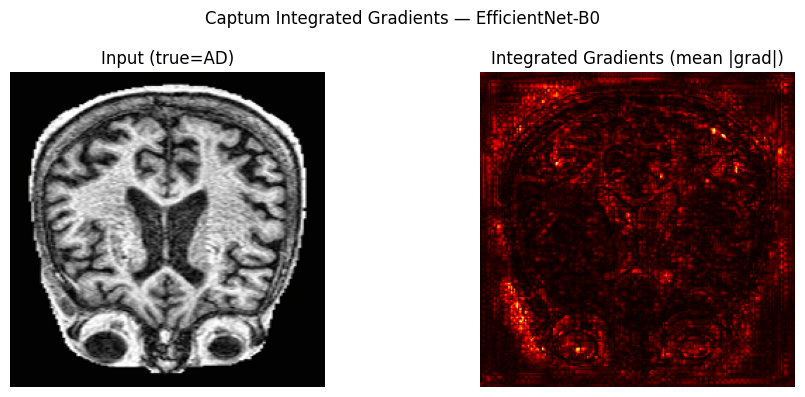

In [22]:
from captum.attr import IntegratedGradients

model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)
with torch.no_grad():
    logits = model(images)
preds = logits.argmax(1)
idx = None
for i in range(images.size(0)):
    if preds[i] == labels[i]:
        idx = i
        break
if idx is None:
    idx = 0
img_b = images[idx : idx + 1].clone().requires_grad_(True)
lbl = labels[idx : idx + 1]

def forward_fn(x):
    return model(x)

ig = IntegratedGradients(forward_fn)
attr = ig.attribute(img_b, target=lbl, n_steps=32)
attr_np = attr.detach().cpu().numpy()[0]
attr_mag = np.abs(attr_np).mean(axis=0)
attr_mag = (attr_mag - attr_mag.min()) / (attr_mag.max() - attr_mag.min() + 1e-8)

mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std = np.array(IMAGENET_STD).reshape(3, 1, 1)
img_np = images[idx].detach().cpu().numpy()
unnorm = np.clip(img_np * std + mean, 0, 1)
rgb = np.transpose(unnorm, (1, 2, 0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(rgb)
axes[0].set_title(f'Input (true={CLASS_NAMES[labels[idx]]})')
axes[0].axis('off')
axes[1].imshow(attr_mag, cmap='hot')
axes[1].set_title('Integrated Gradients (mean |grad|)')
axes[1].axis('off')
plt.suptitle('Captum Integrated Gradients — EfficientNet-B0')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'ig_effnet_sample.png'), dpi=150)
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

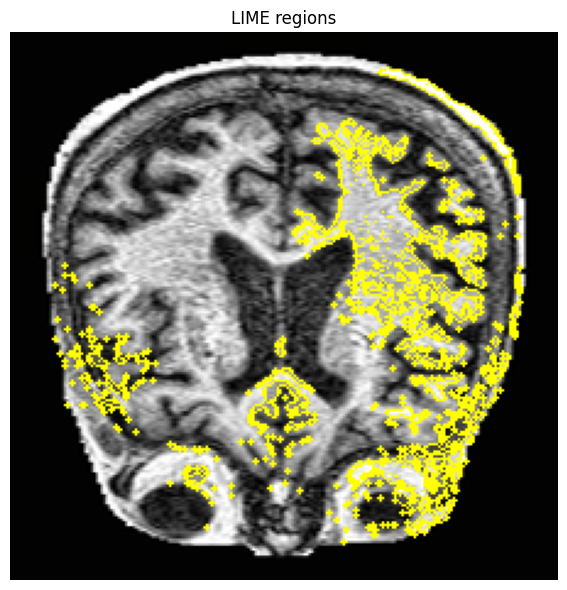

In [24]:
try:
    from lime import lime_image
    from skimage.segmentation import mark_boundaries

    LIME_NUM_SAMPLES = 100

    def predict_rgb(rgb_np):
        a = np.asarray(rgb_np, dtype=np.float32)
        if a.ndim == 3:
            a = a[np.newaxis, ...]
        elif a.ndim != 4:
            raise ValueError(f'LIME predict expected (H,W,C) or (N,H,W,C), got {a.shape}')
        x = torch.from_numpy(a).permute(0, 3, 1, 2).float().to(device)
        x = x / 255.0
        x = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)(x)
        with torch.no_grad():
            out = model(x)
        return torch.softmax(out, dim=1).cpu().numpy()

    rgb255 = (rgb * 255).astype(np.double)
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        rgb255, predict_rgb, top_labels=3, hide_color=0, num_samples=LIME_NUM_SAMPLES, batch_size=32,
    )
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=8, hide_rest=False)
    plt.figure(figsize=(6, 6))
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title('LIME regions')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, 'lime_effnet_sample.png'), dpi=120)
    plt.show()
except Exception as e:
    print(f'LIME skipped: {e}')

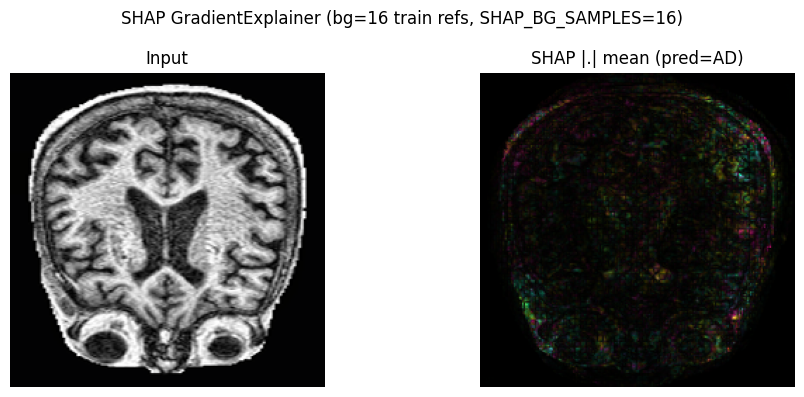

In [27]:
import shap

try:
    _bg_cfg = int(SHAP_BG_SAMPLES)
except NameError:
    _bg_cfg = 16

_n_train = len(train_ds)
_bg_target = max(1, min(_bg_cfg, _n_train))

model.eval()
bg_list, n_bg = [], 0
for xb, _ in train_loader:
    bg_list.append(xb)
    n_bg += xb.size(0)
    if n_bg >= _bg_target:
        break

if not bg_list:
    raise RuntimeError('train_loader returned no batches — run dataset/training cells before this cell.')

background = torch.cat(bg_list, 0)[:_bg_target].to(device).float()
if background.size(0) < 2:
    background = torch.cat([background, background], dim=0)

images_sv, _ = next(iter(test_loader))
xt = images_sv[:1].clone().detach().to(device).float().requires_grad_(True)

mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std = np.array(IMAGENET_STD).reshape(3, 1, 1)
img0 = images_sv[0].detach().cpu().numpy()
rgb_sv = np.clip(np.transpose(img0 * std + mean, (1, 2, 0)), 0, 1)

with torch.no_grad():
    pred_cls = int(model(images_sv[:1].to(device)).argmax(1).item())

try:
    explainer = shap.GradientExplainer(model, background)
    sv = explainer.shap_values(xt)
    if isinstance(sv, list):
        smap = np.asarray(sv[pred_cls][0])
    else:
        smap = np.asarray(sv[0])
        if smap.ndim == 4 and smap.shape[0] == 1:
            smap = smap[0]
    imp = np.abs(smap).mean(axis=0)
    imp = (imp - imp.min()) / (imp.max() - imp.min() + 1e-8)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(rgb_sv)
    ax[0].set_title('Input')
    ax[0].axis('off')
    ax[1].imshow(imp, cmap='coolwarm')
    ax[1].set_title(f'SHAP |.| mean (pred={CLASS_NAMES[pred_cls]})')
    ax[1].axis('off')
    plt.suptitle(f'SHAP GradientExplainer (bg={background.size(0)} train refs, SHAP_BG_SAMPLES={_bg_cfg})')
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, 'shap_effnet_sample.png'), dpi=150)
    plt.show()
except Exception as e:
    print(f'SHAP failed: {e}')
    print(f'Hint: run config cell so SHAP_BG_SAMPLES exists; need train data (got n_train={_n_train}, bg_target={_bg_target}).')

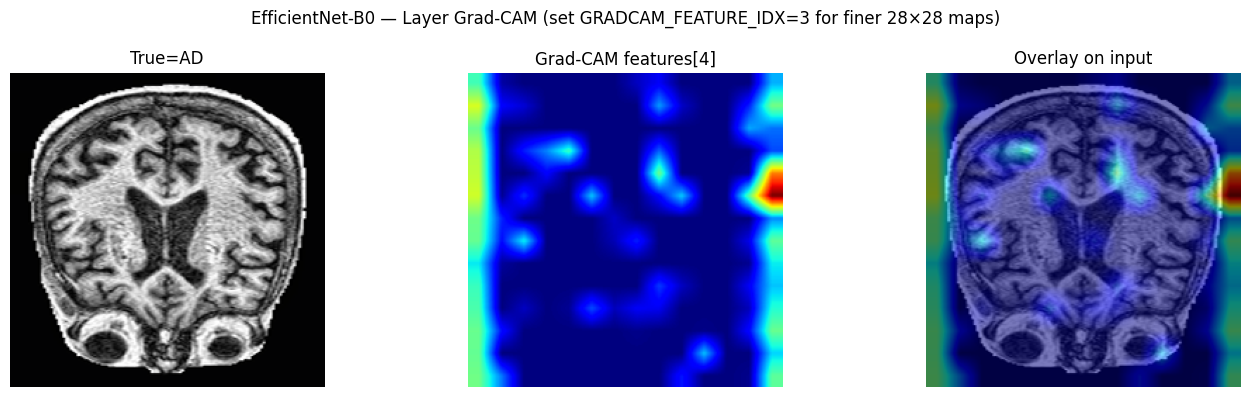

In [28]:
import matplotlib.cm as mpl_cm
import torch.nn.functional as F
from captum.attr import LayerGradCam

try:
    _fi = int(GRADCAM_FEATURE_IDX)
except NameError:
    _fi = 4

model.eval()
cam_layer = model.features[_fi]

images_gc, labels_gc = next(iter(test_loader))
images_gc = images_gc.to(device)
labels_gc = labels_gc.to(device)
with torch.no_grad():
    pred_gc = model(images_gc).argmax(1)
idx_gc = None
for i in range(images_gc.size(0)):
    if pred_gc[i] == labels_gc[i]:
        idx_gc = i
        break
if idx_gc is None:
    idx_gc = 0

xb_gc = images_gc[idx_gc : idx_gc + 1].clone().detach().requires_grad_(True)
yl_gc = labels_gc[idx_gc : idx_gc + 1]

lgc = LayerGradCam(model, cam_layer)
cam_attr = lgc.attribute(xb_gc, target=yl_gc)
if isinstance(cam_attr, tuple):
    cam_attr = cam_attr[0]
ca = cam_attr
if ca.dim() == 4:
    cam_map = ca.mean(dim=1, keepdim=True)
elif ca.dim() == 3:
    cam_map = ca.unsqueeze(1)
else:
    cam_map = ca.unsqueeze(0).unsqueeze(0)
cam_map = F.relu(cam_map.float())
cam_map = F.interpolate(cam_map, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)
cam_np = cam_map.squeeze().detach().cpu().numpy()
cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)

mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std = np.array(IMAGENET_STD).reshape(3, 1, 1)
img_np = images_gc[idx_gc].detach().cpu().numpy()
rgb_gc = np.clip(np.transpose(img_np * std + mean, (1, 2, 0)), 0, 1)

jet_rgb = mpl_cm.jet(cam_np)[..., :3]
overlay = np.clip(0.48 * rgb_gc + 0.52 * jet_rgb, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(rgb_gc)
ax[0].set_title(f'True={CLASS_NAMES[labels_gc[idx_gc]]}')
ax[0].axis('off')
ax[1].imshow(cam_np, cmap='jet')
ax[1].set_title(f'Grad-CAM features[{_fi}]')
ax[1].axis('off')
ax[2].imshow(overlay)
ax[2].set_title('Overlay on input')
ax[2].axis('off')
plt.suptitle('EfficientNet-B0 — Layer Grad-CAM (set GRADCAM_FEATURE_IDX=3 for finer 28×28 maps)')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'gradcam_effnet_sample.png'), dpi=150)
plt.show()